This is my 3rd Portfolio submission that features the unsupervised learning technique, K-means clustering.

Firstly, the initial set up.

Step 1. Initialising, importing libraries and assigning aliases to them.

In [1]:
# import all necessary libraries 

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 
from sklearn.preprocessing import RobustScaler
%matplotlib inline

Step 2. Loading in the data, pre-processing, and checks

Since the data has 2 dimensions/components K-means can be used here (K-means suffers from the "curse of dimensionality" thus for higher dimensional data something like a subpspace clustering algorithm or approach is more apt. SVM cannot be used as it is for supervised learning and classification as opposed to unsupervised learning and clustering). Since both columns have numerical (floats) inputs I do not have to impute and I do not have to drop any data as all 50,000 data entries are filled with floating numbers (no nulls or empty cells).

The CSV itself is structured data as it can be fully represented in a tabular format and the numerical inputs themselves are an example of continous data as discrete data can only be specific values and not floats, this data is not nominal either as it has quantitative values.

In [2]:
ageinc_df = pd.read_csv("age_income.csv") # read data from the file into a Pandas data frame
ageinc_df.head() # quick check to determine data hygiene, first 5 rows printed
ageinc_df.info() # built in function to show that there were no null/empty entries in the CSV, and that the data type are floats for both columns
X = ageinc_df.to_numpy() # Convert the df into numpy array, X for features, to_numpy() used for conversion. Numpy is faster than Pandas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     50000 non-null  float64
 1   Income  50000 non-null  float64
dtypes: float64(2)
memory usage: 781.4 KB


Step 3. Scaling Data

I am scaling the data instead of normalising it as I do not want to change the distribution/shape of the data as K-means assumes the clusters are spherical and isotropic (the radius is approx equal in all directions, raidus means edge to centre distance, diameter is double r). K-means is thus sucsceptible to non-spherical clusters (not optimised for such due to this assumption). 

RobustScaler used instead of StandardScalar as K-means does not handle outliers well and the distribution did not look all that great from a cursory once over (even if a datapoint is much further than any other one it must still be clustered into the nearest centroid and be just as "similar" as a datapoint within the cluster that is much closer). "minimax" was not used as I do not want to scale the range to be between 0-1 and I am not using Neural Networks (NNs) or SVMs. Data was also scaled so outliers do not dominate distance calculations for mean average distance.

Since this is not Regression and I am not predicting any dependent variable I did not use the train test split before scaling.

In [3]:
scaler = RobustScaler() # initialise scaler variable using function imported from scikit-learn
X_scaled = scaler.fit_transform(X)

Step 4. Plotting Data

Scatter plot used to determine the relationship of the data, but in this context for further analysis. Plotting the data as a wave, bar, stem, stairs, or things of that ilk would not be fit for purpose with K-means and would hinder analysis, scatterplots are best for clusters.

Not plotted using scaled data so I can get a clearer analysis on the raw data.

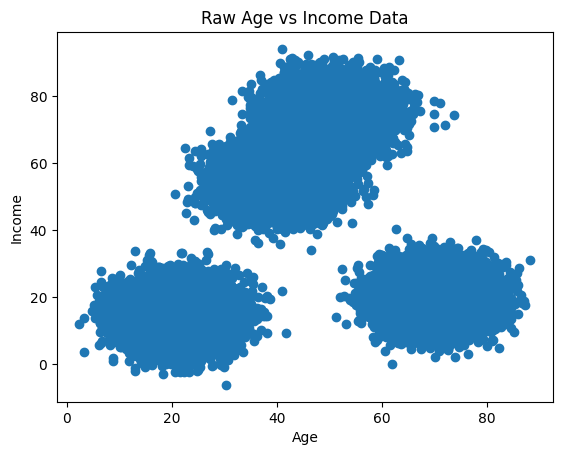

In [4]:
plt.scatter(X[:,0], X[:,1]) # using matplotlib use a scatter plot, ":" plots all rows, 0 and 1 denote the 0th column (Python counts from 0 so the 0th position is the first column, hence column 1 is the "second" position or column aka Income)
plt.xlabel("Age") # as stated in the lab, age is x and income is y
plt.ylabel("Income") # y axis labelled as Income
plt.title("Raw Age vs Income Data") # title the plot/figure
plt.show() # display the figures

Step 5. Finding Optimal K size (number of centroids and clusters, each centroid needs a corresponding cluster and vice bversa) using the Elbow Method

the K-means clustering algorithm partitions data into k amount of clusters by minimising the distances between data points and centroids, to decide the optimal size of k the elbow method is used via plotting the Within-Cluster Sum of Squares (WCSS) against increasing k values, and looking for where the rate of decrease in distance between the data points and centroids slows down dramatically (this is teh dip in the "elbow" shaped graph that looks like the inner elbow where the forearm and upper arm meet). WCSS shows how close the data points are to their centroids and it always decreases as k increases since more clusters reduce the dispersion.

The 2 commonly used metrics for the Elbow Method are inertia and distortion. Distortion measures the average squared distance between every data point and its assigned cluster, it measures how well the clusters represent the data, lower distortion means better representation. Inertia is all the squared distances for each data point to its nearest centroid summed up (added all up), basically square each dp to centroid using Euclidean distance then add them all up. It is described by GeeksforGeeks as the total squared error for clustering (kind of like MSE?), like distortion a lower inertia means better clustering.

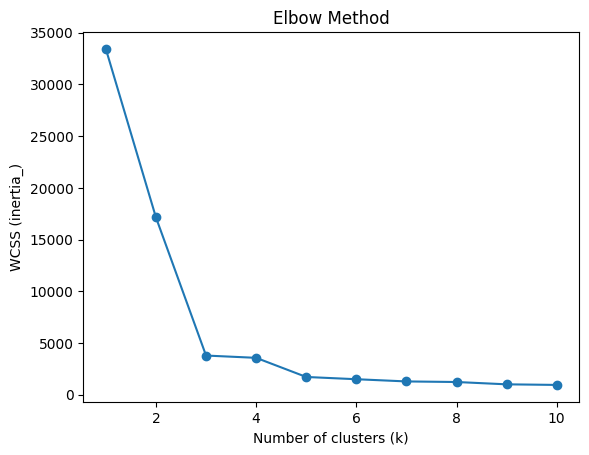

In [5]:
wcss = [] # declared wcss variable, empty list to store WCSS for each k. WCSS shows the closeness of the data points to their cluster centroids.
K_range = range(1, 11) # k range of 1-10 

for k in K_range: # iterate through the loop with k starting at 1 and ending at 10
    kmeans = KMeans(n_clusters=k, random_state=0) # scikit-learn's KMeans algorithm handles the abstraction and fits the data, the clusters have to be equal to the value of k, random_state is set to 0 for reporducability which helps error detection
    kmeans.fit(X_scaled)# run k-means on the data, elbow looks less "uniform" when ran on X_scaled as opposed to X
    wcss.append(kmeans.inertia_)   # inertia_ = WCSS for this k

# Plot the elbow curve
plt.plot(list(K_range), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (inertia_)")
plt.show()

# using inertia and the scaled data my ideal k is shown to be 5, used inertia as it was built in and common sentiment is that they both yield good Elbow methods regardless. towardsdatasience describe WCSS as inertia anyway.
# using the raw data of X gives my optimal k value as 4
# opt_k being 4 gives the best cluster spread as shown in the final step

Step 6. Running the algorithm using the identified optimal k value
Step 7. Produce labels for the data and print out their unique values

Code explanation

# k-means++ is a smart centroid initilisation method for the k-means algorithm and it assigns the first centroid randomly before selecting the remaining centroids based on the max squared distance, the goal is to spread out the initial centroids and push the centroids as far away from each otehr as possible.
# n_clusters is the amount of clusters to form as well as the number of centroids to create
# n_init is the number of times the k-means algorithm is ran with different cenrtoid seeds. Then the final results is the best output of n_init in terms of WCSS (inertia)

In [6]:
optimal_k = 4
k_means_final = KMeans(init = "k-means++", n_clusters = optimal_k, random_state=0, n_init = 12) # final k-means so that the cluster centres are not 10 from the final loop
k_means_final.fit(X_scaled) # train the final k-means
labels = k_means_final.labels_ # initialise the labels variable using the built in sklearn  KMeans labels_ func
print(labels) # print the cluster labels

# found from IBM clus k means cust seg  ipynb

[0 0 2 ... 1 1 0]


Step 8. Calculate the coordinates of the centroids and print them

In [7]:
centroids = k_means_final.cluster_centers_ # assign cluster centres to centroids variable
print("Centroid coordinates: \n", centroids) # \n used for efficiency

Centroid coordinates: 
 [[-0.81381238 -0.463102  ]
 [ 0.17393242  0.79580208]
 [ 0.84027378 -0.35865849]
 [-0.17808397  0.38027457]]


Setp 9. Final Data Plotting

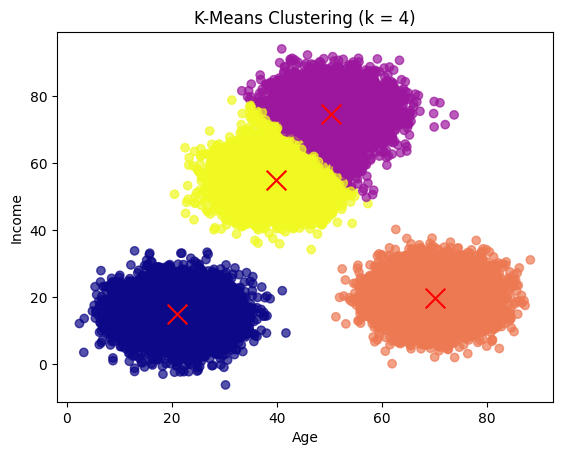

In [8]:
# Plot final clustered data
plt.scatter(X[:,0], X[:,1], c=labels, cmap='plasma', alpha=0.7) # colour map as plasma, alpha for transparency 

# Unscaled the centroid data as it was not displaying proprely otherwise, it is now back in real ages and incomes. Since k-means was trained on scaled data and I am plotting using unscaled it was the only way to fix the clusters being too small.
centroids_unscaled = scaler.inverse_transform(k_means_final.cluster_centers_)
plt.scatter(centroids_unscaled[:,0], centroids_unscaled[:,1], # all data in rows and columns
            marker='x', s=200, c='red') # red as the colour of the marker, x as the marker of teh centroid, c for colour

# Labels and title
plt.xlabel("Age")
plt.ylabel("Income")
plt.title(f"K-Means Clustering (k = {optimal_k})") # cluster plot when k = optimal_k

plt.show()

# unscaled data may be best for potentially retaining initial data accuracy, perhaps during my cursory glance I did not account for the difference in exponentials (assuming E in the CSV stands for exponential) or rather floats are negligent.
# I at least experimented more though.

References:

https://en.wikipedia.org/wiki/Clustering_high-dimensional_data
https://www.bbc.co.uk/bitesize/guides/zyqc9qt/revision/3
https://www.geeksforgeeks.org/machine-learning/demonstration-of-k-means-assumptions/
https://stackoverflow.com/questions/13187778/convert-pandas-dataframe-to-numpy-array
https://www.reddit.com/r/learnpython/comments/whjo2j/numpy_array_vs_pandas_dataframe/
https://www.atlassian.com/data/charts/what-is-a-scatter-plot
https://matplotlib.org/stable/plot_types/index.html
https://www.geeksforgeeks.org/python/matplotlib-pyplot-show-in-python/
https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/
https://www.analyticsvidhya.com/blog/2021/01/in-depth-intuition-of-k-means-clustering-algorithm-in-machine-learning/
https://www.w3schools.com/python/python_ml_k-means.asp
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
https://stackoverflow.com/questions/50520310/comparison-of-different-way-of-implementing-the-elbow-method
https://neptune.ai/blog/k-means-clustering#:~:text=K%2Dmeans%2B%2B%20is%20a,as%20possible%20from%20one%20another.
https://towardsdatascience.com/a-deep-dive-into-k-means-f9a1ef2490f8/#:~:text=Mathematically%2C%20k%2Dmeans%20focuses%20minimizing,within%20cluster%20sum%20of%20squares.
https://matplotlib.org/stable/users/explain/colors/colormaps.html



